In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
import os

import gfdl_utils.core as gu
import CM4Xutils
import cftime
import numpy as np
import pandas as pd
import xarray as xr
import xgcm
import xhistogram
import xwmt

import cmocean
import matplotlib.colors as colors
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.dates as mdates
plt.rcParams.update({'font.size': 11})

In [3]:
from common import *

### Load ocean CFC concentration observations

In [4]:
glo = xr.open_dataset("../data/obs/glodap_v1/glodap_cfc.nc") # CFC concentrations [pmol / kg]

# Estimate volumes of data cells
glo['dz'] = xr.ones_like(glo['depth'])
glo['dz'].data = np.diff(glo['depth_bnds'])
R = 6378.1e3 # radius of Earth in meters
glo['dA'] = R**2 * np.abs(np.sin(np.deg2rad(glo['lat']+0.5)) - np.sin(np.deg2rad(glo['lat']-0.5))) * np.deg2rad((glo['lon']+0.5) - (glo['lon']-0.5))
glo['volcello'] = glo.dz * glo.dA

mol_per_pmol = 1e-12
rho0 = 1035. # reference density [kg/m^3]

### Load integrated CM4X tracer outputs

In [5]:
ds = {
    model: xr.open_dataset(f"../data/processed/tracer_integrals_{model}_forced.nc")
    for model in ["CM4Xp25", "CM4Xp125"]
}

### FIGURE XX: Comparison of vertically-integrated CFC content against GLODAPv1 observations

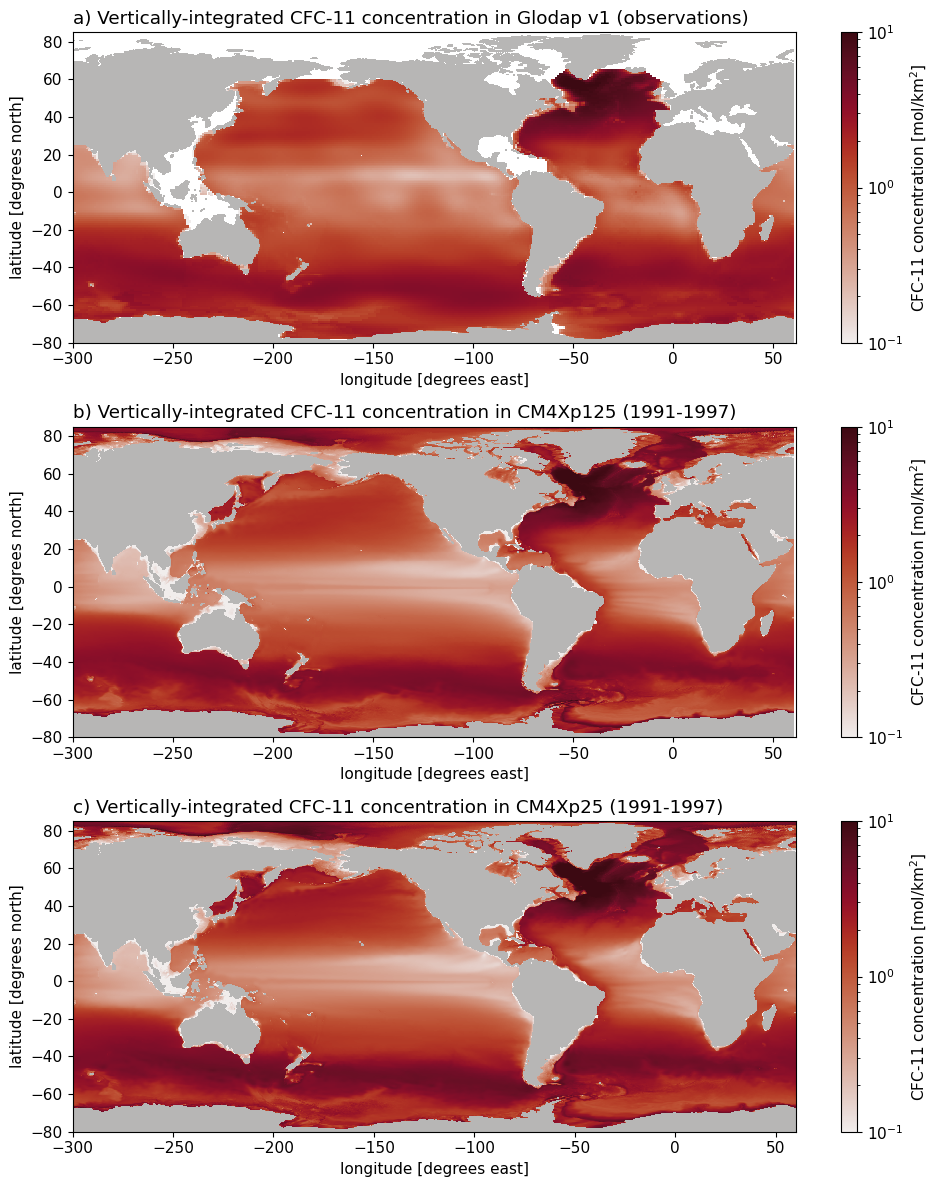

In [8]:
fig, axes = plt.subplots(3,1,figsize=(10, 12))

ax = axes[0]
cfc11_zint = (glo.CFC11*mol_per_pmol*rho0*glo.dz*m2_per_km2).sum("depth").roll(shifts={"lon":120}, roll_coords=True)
cfc11_zint = cfc11_zint.assign_coords(
    {"lon": np.mod(cfc11_zint.lon.values + 300, 360) - 300}
)
pc = ax.pcolor(
    cfc11_zint.lon,
    cfc11_zint.lat,
    cfc11_zint,
    norm=colors.LogNorm(vmin=1e-1, vmax=10),
    cmap=cmocean.cm.amp
)
ax.pcolor(
    ds["CM4Xp125"].geolon,
    ds["CM4Xp125"].geolat,
    ds["CM4Xp125"].deptho.where(ds["CM4Xp125"].deptho==0.) + 1,
    cmap=cmocean.cm.gray,
    vmin=0, vmax=1.3
)
plt.colorbar(pc, ax=ax, label=r"CFC-11 concentration [mol/km$^{2}$]")

ax = axes[1]
pc = ax.pcolor(
    ds["CM4Xp125"].geolon_c,
    ds["CM4Xp125"].geolat_c,
    ds["CM4Xp125"].cfc11_vertical_int,
    norm=colors.LogNorm(vmin=1e-1, vmax=10),
    cmap=cmocean.cm.amp
)
ax.pcolor(
    ds["CM4Xp125"].geolon,
    ds["CM4Xp125"].geolat,
    ds["CM4Xp125"].deptho.where(ds["CM4Xp125"].deptho==0.) + 1,
    cmap=cmocean.cm.gray,
    vmin=0, vmax=1.3
)
plt.colorbar(pc, ax=ax, label=r"CFC-11 concentration [mol/km$^{2}$]")

ax = axes[2]
pc = ax.pcolor(
    ds["CM4Xp25"].geolon_c,
    ds["CM4Xp25"].geolat_c,
    ds["CM4Xp25"].cfc11_vertical_int,
    norm=colors.LogNorm(vmin=1e-1, vmax=10),
    cmap=cmocean.cm.amp
)
ax.pcolor(
    ds["CM4Xp25"].geolon,
    ds["CM4Xp25"].geolat,
    ds["CM4Xp25"].deptho.where(ds["CM4Xp25"].deptho==0.) + 1,
    cmap=cmocean.cm.gray,
    vmin=0, vmax=1.3
)
plt.colorbar(pc, ax=ax, label=r"CFC-11 concentration [mol/km$^{2}$]")

titles = [
    "a) Vertically-integrated CFC-11 concentration in Glodap v1 (observations)",
    "b) Vertically-integrated CFC-11 concentration in CM4Xp125 (1991-1997)",
    "c) Vertically-integrated CFC-11 concentration in CM4Xp25 (1991-1997)",
    ]
for ax, title in zip(axes, titles):
    ax.set_ylim(-80, 85)
    ax.set_title(title, loc="left")
    ax.set_xlabel("longitude [degrees east]")
    ax.set_ylabel("latitude [degrees north]")

fig.tight_layout()
plt.savefig("../figures/SFig1_glodap_observational_validation_zint.png", dpi=400, bbox_inches="tight")

### FIGURE XX: Comparison of zonally-integrated CFC content against GLODAPv1 observations

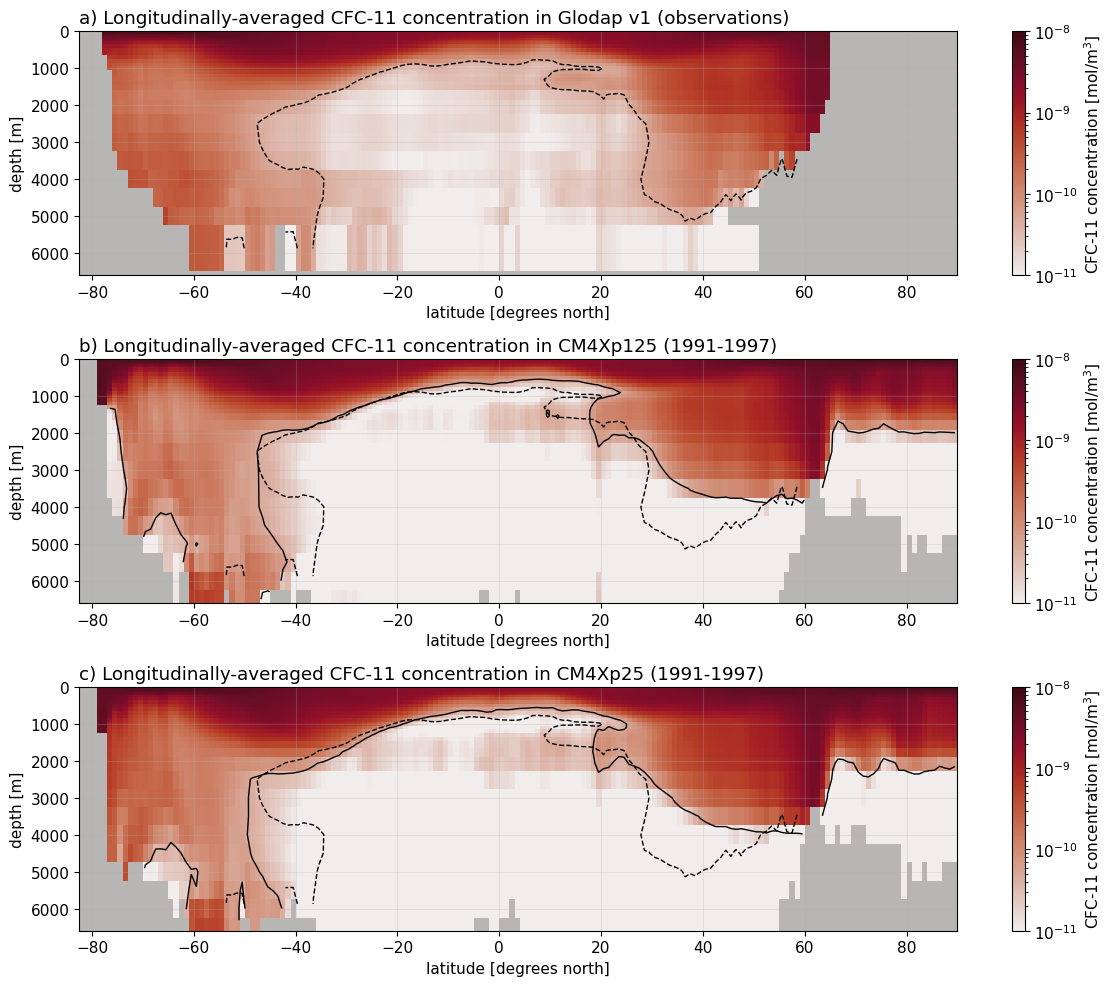

In [11]:
fig, axes = plt.subplots(3,1, figsize=(12, 10))

# Glodap v1
ax = axes[0]
ax.set_facecolor(facecolor)

dlat = 1.
lat_bins_glodap = np.arange(-90., 90.+dlat, dlat)
d_bins_glodap  = glo.depth_bnds

cfc11_zlat_av = (glo.CFC11*mol_per_pmol*rho0).mean("lon", skipna=True)
cfc11_zlat_av_glodap = cfc11_zlat_av.copy()

pc = ax.pcolormesh(
    lat_bins_glodap,
    d_bins_glodap,
    cfc11_zlat_av,
    norm=colors.LogNorm(vmin=1e-11, vmax=1e-8),
    cmap=cmocean.cm.amp
)
ct = ax.contour(
    0.5*(lat_bins_glodap[:-1]+lat_bins_glodap[1:]),
    0.5*(d_bins_glodap.values[:-1]+d_bins_glodap.values[1:]),
    cfc11_zlat_av_glodap,
    levels=[5e-11],
    colors="k",
    linewidths=1.,
    linestyles="--",
)
plt.colorbar(pc, ax=ax, label=r"CFC-11 concentration [mol/m$^{3}$]")

# CM4Xp125
ax = axes[1]
ax.set_facecolor(facecolor)

pc = ax.pcolormesh(
    ds["CM4Xp125"].lat,
    ds["CM4Xp125"].z_l,
    ds["CM4Xp125"].cfc11_zonal_int,
    norm=colors.LogNorm(vmin=1e-11, vmax=1e-8),
    cmap=cmocean.cm.amp
)
plt.colorbar(pc, ax=ax, label=r"CFC-11 concentration [mol/m$^{3}$]")
ct = ax.contour(
    ds["CM4Xp125"].lat,
    ds["CM4Xp125"].z_l,
    ds["CM4Xp125"].cfc11_zonal_int,
    levels=[5e-11],
    colors="k",
    linewidths=1.
)
ct = ax.contour(
    0.5*(lat_bins_glodap[:-1]+lat_bins_glodap[1:]),
    0.5*(d_bins_glodap.values[:-1]+d_bins_glodap.values[1:]),
    cfc11_zlat_av_glodap,
    levels=[5e-11],
    colors="k",
    linewidths=1.,
    linestyles="--",
)

# CM4Xp25
ax = axes[2]
ax.set_facecolor(facecolor)

pc = ax.pcolormesh(
    ds["CM4Xp25"].lat,
    ds["CM4Xp25"].z_l,
    ds["CM4Xp25"].cfc11_zonal_int,
    norm=colors.LogNorm(vmin=1e-11, vmax=1e-8),
    cmap=cmocean.cm.amp
)
plt.colorbar(pc, ax=ax, label=r"CFC-11 concentration [mol/m$^{3}$]")
ct = ax.contour(
    ds["CM4Xp25"].lat,
    ds["CM4Xp25"].z_l,
    ds["CM4Xp25"].cfc11_zonal_int,
    levels=[5e-11],
    colors="k",
    linewidths=1.
)
ct = ax.contour(
    0.5*(lat_bins_glodap[:-1]+lat_bins_glodap[1:]),
    0.5*(d_bins_glodap.values[:-1]+d_bins_glodap.values[1:]),
    cfc11_zlat_av_glodap,
    levels=[5e-11],
    colors="k",
    linewidths=1.,
    linestyles="--",
)

titles = [
    "a) Longitudinally-averaged CFC-11 concentration in Glodap v1 (observations)",
    "b) Longitudinally-averaged CFC-11 concentration in CM4Xp125 (1991-1997)",
    "c) Longitudinally-averaged CFC-11 concentration in CM4Xp25 (1991-1997)",
]
for ax, title in zip(axes, titles):
    ax.set_title(title, loc="left")
    ax.set_xlabel("latitude [degrees north]")
    ax.set_ylabel("depth [m]")
    ax.set_ylim(6600, 0)
    ax.set_xlim(-82.5, 90)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig("../figures/SFig2_glodap_observational_validation_lonav.png", dpi=400, bbox_inches="tight")